In [6]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

print("Libraries imported successfully")


Libraries imported successfully


In [8]:

DATA_PATH = "teams_data.csv"


def generate_team_data(n_teams=60, seed=42, save_path=DATA_PATH):
    """Generate synthetic team performance data (deterministic via seed)."""
    np.random.seed(seed)
    data = {
        "team_name": [f"Team_{i}" for i in range(1, n_teams + 1)],
        "wins": np.random.randint(15, 68, n_teams),
        "points_for": np.round(np.random.uniform(100, 128, n_teams), 1),
        "points_against": np.round(np.random.uniform(100, 125, n_teams), 1),
        "rebounds": np.round(np.random.uniform(40, 53, n_teams), 1),
        "assists": np.round(np.random.uniform(22, 33, n_teams), 1),
        "field_goal_percent": np.round(np.random.uniform(42, 53, n_teams), 1),
        "three_point_percent": np.round(np.random.uniform(30, 43, n_teams), 1),
        "turnovers": np.round(np.random.uniform(11, 19, n_teams), 1),
    }
    df = pd.DataFrame(data)
    df["losses"] = 82 - df["wins"]

    # Assign a unique league position based on wins (1 = best record)
    df["league_position"] = df["wins"].rank(ascending=False, method="first").astype(int)
    df = df.sort_values("league_position").reset_index(drop=True)

    # Bucket standings into four tiers -- a more learnable classification
    # target than predicting the exact 1-of-60 finishing position.
    def tier(pos, n=n_teams):
        q = n / 4
        if pos <= q:
            return "Elite"
        elif pos <= 2 * q:
            return "Contender"
        elif pos <= 3 * q:
            return "Average"
        else:
            return "Struggling"

    df["performance_tier"] = df["league_position"].apply(tier)

    cols = [
        "team_name", "wins", "losses", "points_for", "points_against",
        "rebounds", "assists", "field_goal_percent", "three_point_percent",
        "turnovers", "league_position", "performance_tier",
    ]
    df = df[cols]
    df.to_csv(save_path, index=False)
    print(f"✅ Generated {n_teams} teams -> saved to {save_path}")
    return df


if not os.path.exists(DATA_PATH):
    print(f"⚠️  {DATA_PATH} not found locally — generating synthetic data instead.")
    generate_team_data(n_teams=60, seed=42, save_path=DATA_PATH)
else:
    print("Found {DATA_PATH} — using it directly.")


Found {DATA_PATH} — using it directly.


In [10]:

class TeamPerformancePredictor:
    """Predicts a team's league position from its season statistics."""

    def __init__(self):
        self.model = None
        self.scaler = StandardScaler()
        self.feature_names = None
        self.df = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

    def load_data(self, csv_path):
        """Load team data from CSV."""
        self.df = pd.read_csv(csv_path)
        print(f" Loaded {len(self.df)} teams")
        print(f"Dataset shape: {self.df.shape}")
        print(f"Columns: {self.df.columns.tolist()}")
        return self.df

    def prepare_data(self, target_column="performance_tier", test_size=0.2):
        """Split into train/test sets and scale features."""
        # Drop identifier columns and any column that would leak the target
        # (league_position is used to derive performance_tier, so it must
        # not be used as a predictive feature).
        drop_cols = {"team_name", target_column, "league_position"}
        drop_cols = [c for c in drop_cols if c in self.df.columns]
        X = self.df.drop(columns=drop_cols)
        y = self.df[target_column]
        self.feature_names = X.columns.tolist()

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )
        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)

        print(" Data prepared")
        print(f"Training set: {self.X_train.shape}")
        print(f"Test set: {self.X_test.shape}")

    def train_model(self, model_type="random_forest"):
        """Train the prediction model (random_forest or gradient_boosting)."""
        if model_type == "random_forest":
            self.model = RandomForestClassifier(
                n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
            )
        elif model_type == "gradient_boosting":
            self.model = GradientBoostingClassifier(
                n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
            )
        else:
            raise ValueError("model_type must be 'random_forest' or 'gradient_boosting'")

        self.model.fit(self.X_train, self.y_train)
        print(f" Model trained ({model_type})")

    def evaluate_model(self):
        """Evaluate model performance on the held-out test set."""
        y_pred = self.model.predict(self.X_test)
        accuracy = accuracy_score(self.y_test, y_pred)
        print("\n Model Performance")
        print(f"Accuracy: {accuracy:.4f}")
        print("\nClassification Report:\n")
        print(classification_report(self.y_test, y_pred, zero_division=0))
        return y_pred

    def get_feature_importance(self, top_n=10):
        """Return a DataFrame of the most important features."""
        importances = self.model.feature_importances_
        feature_importance_df = pd.DataFrame(
            {"feature": self.feature_names, "importance": importances}
        ).sort_values("importance", ascending=False)
        print(f"\n Top {top_n} Important Features:")
        print(feature_importance_df.head(top_n))
        return feature_importance_df

    def visualize_importance(self, top_n=10):
        """Bar chart of feature importance."""
        feature_importance_df = self.get_feature_importance(top_n)
        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=feature_importance_df.head(top_n),
            x="importance",
            y="feature",
            palette="viridis",
        )
        plt.title("Top Features Predicting Team Performance", fontsize=14, fontweight="bold")
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
        plt.show()

    def plot_confusion_matrix(self, y_pred):
        """Heatmap of predicted vs. actual league positions."""
        cm = confusion_matrix(self.y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix")
        plt.ylabel("Actual")
        plt.xlabel("Predicted")
        plt.tight_layout()
        plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
        plt.show()

    def predict_team_outcome(self, team_stats):
        """
        Predict the league position for a new team.
        team_stats: dict of the same feature columns used in training.
        """
        team_df = pd.DataFrame([team_stats])
        team_df = team_df[self.feature_names]
        team_scaled = self.scaler.transform(team_df)
        prediction = self.model.predict(team_scaled)[0]
        confidence = self.model.predict_proba(team_scaled).max()
        return {"predicted_position": prediction, "confidence": confidence}

    def save_model(self, filepath="team_predictor.pkl"):
        """Persist the trained model + scaler to disk."""
        joblib.dump(self.model, filepath)
        joblib.dump(self.scaler, "scaler.pkl")
        print(f"Model saved to {filepath}")
        print(" Scaler saved to scaler.pkl")

    def load_model(self, filepath="team_predictor.pkl", scaler_path="scaler.pkl"):
        """Load a previously trained model + scaler."""
        self.model = joblib.load(filepath)
        self.scaler = joblib.load(scaler_path)
        print(f" Model loaded from {filepath}")



            wins     losses  points_for  points_against   rebounds    assists  \
count  60.000000  60.000000   60.000000       60.000000  60.000000  60.000000   
mean   41.483333  40.516667  113.581667      111.961667  46.348333  28.418333   
std    15.846180  15.846180    8.310408        7.503402   3.762054   3.115597   
min    16.000000  15.000000  100.200000      100.200000  40.100000  22.200000   
25%    29.000000  27.500000  106.800000      105.975000  42.900000  26.000000   
50%    39.000000  43.000000  113.850000      110.550000  47.150000  28.850000   
75%    54.500000  53.000000  121.375000      119.275000  49.075000  31.325000   
max    67.000000  66.000000  127.600000      124.600000  52.200000  32.900000   

       field_goal_percent  three_point_percent  turnovers  league_position  
count           60.000000            60.000000  60.000000        60.000000  
mean            46.963333            36.475000  14.981667        30.500000  
std              3.163776             3

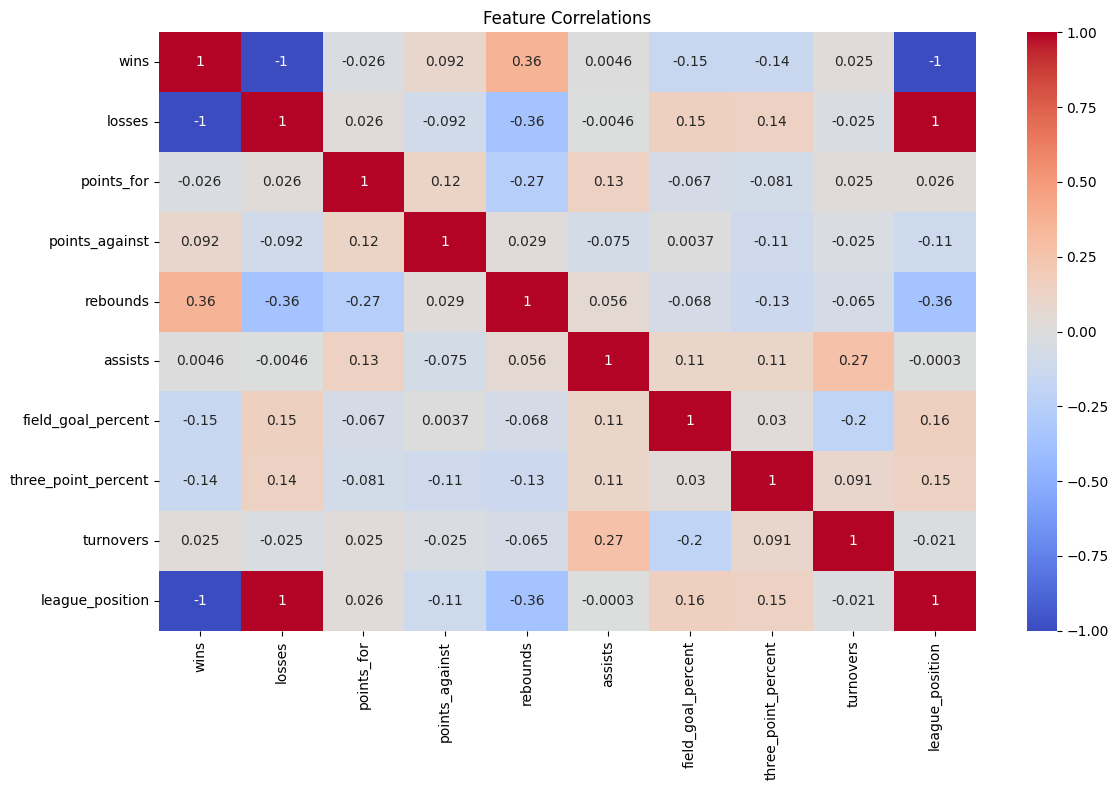

In [11]:
_preview_df = pd.read_csv(DATA_PATH)
print(_preview_df.describe())

plt.figure(figsize=(12, 8))
sns.heatmap(_preview_df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlations")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()



 Loaded 60 teams
Dataset shape: (60, 12)
Columns: ['team_name', 'wins', 'losses', 'points_for', 'points_against', 'rebounds', 'assists', 'field_goal_percent', 'three_point_percent', 'turnovers', 'league_position', 'performance_tier']
 Data prepared
Training set: (48, 9)
Test set: (12, 9)
 Model trained (random_forest)

 Model Performance
Accuracy: 0.9167

Classification Report:

              precision    recall  f1-score   support

     Average       0.75      1.00      0.86         3
   Contender       1.00      0.67      0.80         3
       Elite       1.00      1.00      1.00         3
  Struggling       1.00      1.00      1.00         3

    accuracy                           0.92        12
   macro avg       0.94      0.92      0.91        12
weighted avg       0.94      0.92      0.91        12


 Top 8 Important Features:
               feature  importance
0                 wins    0.400282
1               losses    0.372747
4             rebounds    0.044688
7  three_point_

/tmp/ipykernel_610/3698777355.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


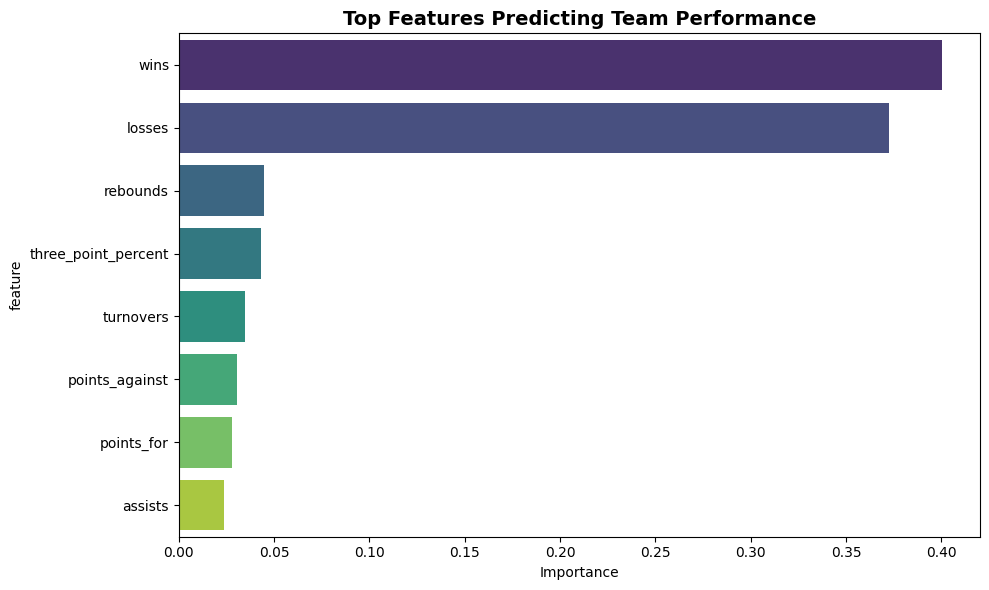

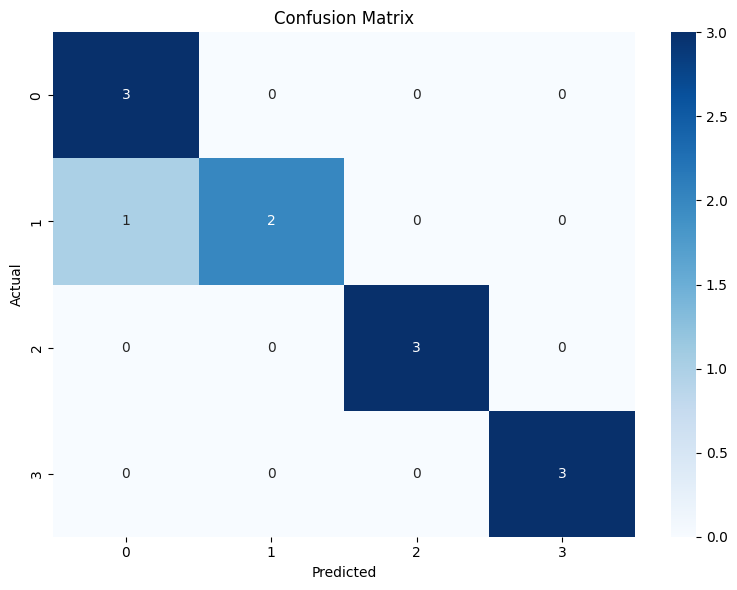

Model saved to team_predictor.pkl
 Scaler saved to scaler.pkl


In [12]:

predictor = TeamPerformancePredictor()

predictor.load_data(DATA_PATH)
predictor.prepare_data(target_column="performance_tier")
predictor.train_model(model_type="random_forest")

y_pred = predictor.evaluate_model()
predictor.visualize_importance(top_n=8)
predictor.plot_confusion_matrix(y_pred)
predictor.save_model(filepath="team_predictor.pkl")



In [13]:
new_team = {
    "wins": 50,
    "losses": 32,
    "points_for": 117.5,
    "points_against": 109.8,
    "rebounds": 46.5,
    "assists": 28.2,
    "field_goal_percent": 50.1,
    "three_point_percent": 37.5,
    "turnovers": 13.5,
}

result = predictor.predict_team_outcome(new_team)
print(
    f"\n Prediction: Position {result['predicted_position']} "
    f"(Confidence: {result['confidence']:.2%})"
)



 Prediction: Position Contender (Confidence: 77.00%)
